# EE5531 — Reinforcement Learning Based Control

# Programming part of Assignment 1: Python, MDPs, and Function Approximation

### Objective

This assignment provides hands-on experience with:

1. Python classes and objects.
2. Implementing an MDP environment.
3. Deterministic and stochastic state transitions.
4. Understanding transition probabilities empirically.
5. PyTorch tensors and automatic differentiation.
6. Neural-network-based function approximation.
7. Approximation of a value function using a neural network.

---

## Instructions

- Complete all sections of the assignment.
- Replace every `TODO` with appropriate Python code.
- Execute all cells and ensure that the notebook runs without errors.
- Wherever a question asks for an explanation, provide your answer in a Markdown cell.
- Include appropriate plots, tables, and observations wherever requested.
- Use meaningful variable and function names.

# Part A — Python Classes and Objects

In Python, a **class** provides a blueprint for creating objects.

A class can contain:

- **Attributes** — variables that store information associated with an object.
- **Methods** — functions that define the behavior of an object.

In this assignment, you will implement a simple grid-world environment as a Python class.

# Part B — Custom GridWorld Environment

## Objective

Implement a custom environment class called `AgentInGridWorld` that simulates an agent navigating a two-dimensional grid.

## Environment Description

Consider a **5 × 5 grid** with coordinates

$$(x,y), \qquad x,y \in \{0,1,2,3,4\}.
$$
The environment has the following characteristics:

- **Initial position:** `(0,0)`
- **Goal position:** `(4,4)`
- **Blocked cell:** `(2,2)`

### Action Space

The agent can choose one of the following actions:

- `up`
- `down`
- `left`
- `right`

The agent cannot move outside the grid. The blocked cell `(2,2)` cannot be entered.

## Reward Structure

| Event | Reward |
|---|---:|
| Reaching the goal | +10 |
| Attempting to move outside the grid | -1 |
| Attempting to enter the blocked cell | -2 |
| Any other valid movement | -0.1 |

Once the agent reaches the goal, it should be automatically re-initialized at `(0,0)`.

---

## Methods to Implement

Implement the following methods:

### `__init__()`

Initialize:

- grid dimensions,
- initial position,
- goal position,
- blocked cell,
- current position,
- cumulative reward.

### `get_position()`

Returns the current position of the agent as `(x,y)`.

### `get_reward()`

Returns the cumulative reward accumulated by the agent.

### `take_action(actions)`

Accepts a **list of actions** and executes them sequentially. For example:

```python
agent.take_action(['up', 'right', 'right', 'down', 'right'])

In [1]:
class AgentInGridWorld:

    def __init__(self):
        self.grid_size = 5
        self.initial_position = (0, 0)
        self.goal = (4, 4)
        self.blocked_cell = (2, 2)
        self.current_position = self.initial_position
        self.cumulative_reward = 0.0
        self.boundary_collisions = 0
        self.blocked_attempts = 0
        self.visited_states = [self.current_position]
        self.goal_reached = False

    def get_position(self):
        return self.current_position

    def get_reward(self):
        return self.cumulative_reward

    def take_action(self, actions):
        for action in actions:
            x, y = self.current_position
            new_position = (x, y)

            if action == "up":
                new_position = (x, y + 1)
            elif action == "down":
                new_position = (x, y - 1)
            elif action == "left":
                new_position = (x - 1, y)
            elif action == "right":
                new_position = (x + 1, y)
            else:
                raise ValueError("Invalid action: " + str(action))

            # Boundary collision
            if not (0 <= new_position[0] < self.grid_size and
                    0 <= new_position[1] < self.grid_size):
                self.cumulative_reward -= 1
                self.boundary_collisions += 1
                self.visited_states.append(self.current_position)
                continue

            # Blocked cell
            if new_position == self.blocked_cell:
                self.cumulative_reward -= 2
                self.blocked_attempts += 1
                self.visited_states.append(self.current_position)
                continue

            # Valid movement
            self.current_position = new_position

            if self.current_position == self.goal:
                self.cumulative_reward += 10
                self.goal_reached = True
                self.visited_states.append(self.current_position)
                self.current_position = self.initial_position
            else:
                self.cumulative_reward -= 0.1
                self.visited_states.append(self.current_position)

    def reset(self):
        self.current_position = self.initial_position
        self.cumulative_reward = 0.0
        self.boundary_collisions = 0
        self.blocked_attempts = 0
        self.visited_states = [self.current_position]
        self.goal_reached = False

## Task 1 — Test the Environment

Create an instance of the environment and test your implementation.

Use an appropriate sequence of actions.

Report:

1. The sequence of states visited.
2. The cumulative reward.
3. The number of boundary collisions.
4. The number of attempts to enter the blocked cell.
5. Whether the goal was reached.

In [2]:
agent = AgentInGridWorld()

# Path from (0,0) to the goal (4,4).
# It deliberately includes one move outside the grid and one move into the
# blocked cell (2,2) so that all four reward cases can be checked.
actions = [
    "down",                         # boundary collision
    "right", "right",               # (1,0) -> (2,0)
    "up",                           # (2,1)
    "up",                           # tries to enter blocked cell (2,2)
    "right",                        # (3,1)
    "up", "up", "up",               # (3,2) -> (3,4)
    "right"                         # (4,4) : goal
]

agent.take_action(actions)

print("States visited:", agent.visited_states)
print("Final Position:", agent.get_position())
print("Cumulative Reward:", agent.get_reward())
print("Boundary collisions:", agent.boundary_collisions)
print("Blocked-cell attempts:", agent.blocked_attempts)
print("Goal reached:", agent.goal_reached)

States visited: [(0, 0), (0, 0), (1, 0), (2, 0), (2, 1), (2, 1), (3, 1), (3, 2), (3, 3), (3, 4), (4, 4)]
Final Position: (0, 0)
Cumulative Reward: 6.299999999999999
Boundary collisions: 1
Blocked-cell attempts: 1
Goal reached: True


# Part C — Stochastic Environment

So far, the environment is deterministic: if the agent requests an action, that action is executed.

Now modify the environment to introduce **stochastic transitions**.

Suppose the agent requests action \(a\). The actual action executed by the environment is selected according to $$ P(A_t=a)=0.7$$

and the remaining probability is distributed uniformly among the other three actions:

$$
P(A_t=a')=0.1,
\qquad a'\neq a.
$$

For example, if the requested action is `up`:

| Actual action | Probability |
|---|---:|
| `up` | 0.7 |
| `down` | 0.1 |
| `left` | 0.1 |
| `right` | 0.1 |

---

## Task 2 — Transition Probability

Implement a **private method**

```python
_apply_transition_probability(action)

In [3]:
import random

class AgentInGridWorld:

    def __init__(self):
        self.grid_size = 5
        self.initial_position = (0, 0)
        self.goal = (4, 4)
        self.blocked_cell = (2, 2)
        self.current_position = self.initial_position
        self.cumulative_reward = 0.0
        self.boundary_collisions = 0
        self.blocked_attempts = 0
        self.visited_states = [self.current_position]
        self.goal_reached = False

    def get_position(self):
        return self.current_position

    def get_reward(self):
        return self.cumulative_reward

    def reset(self):
        self.current_position = self.initial_position
        self.cumulative_reward = 0.0
        self.boundary_collisions = 0
        self.blocked_attempts = 0
        self.visited_states = [self.current_position]
        self.goal_reached = False

    def _apply_transition_probability(self, action):
        actions = ["up", "down", "left", "right"]

        if action not in actions:
            raise ValueError("Invalid action: " + str(action))

        # Requested action has probability 0.7.
        if random.random() < 0.7:
            return action

        # The other three actions have probability 0.1 each.
        other_actions = [a for a in actions if a != action]
        return random.choice(other_actions)

    def take_action(self, actions):
        for requested_action in actions:
            actual_action = self._apply_transition_probability(requested_action)

            x, y = self.current_position
            new_position = (x, y)

            if actual_action == "up":
                new_position = (x, y + 1)
            elif actual_action == "down":
                new_position = (x, y - 1)
            elif actual_action == "left":
                new_position = (x - 1, y)
            elif actual_action == "right":
                new_position = (x + 1, y)

            old_position = self.current_position

            if not (0 <= new_position[0] < self.grid_size and
                    0 <= new_position[1] < self.grid_size):
                reward = -1
                self.boundary_collisions += 1

            elif new_position == self.blocked_cell:
                reward = -2
                self.blocked_attempts += 1

            else:
                self.current_position = new_position
                if self.current_position == self.goal:
                    reward = 10
                    self.goal_reached = True
                    self.visited_states.append(self.current_position)
                    print(f"Requested action: {requested_action:5s}  Actual action: {actual_action:5s}  "
                          f"Resulting state: {self.current_position}  Reward: {reward}")
                    self.cumulative_reward += reward
                    self.current_position = self.initial_position
                    self.visited_states.append(self.current_position)
                    continue
                else:
                    reward = -0.1

            self.cumulative_reward += reward
            self.visited_states.append(self.current_position)

            print(f"Requested action: {requested_action:5s}  Actual action: {actual_action:5s}  "
                  f"Resulting state: {self.current_position}  Reward: {reward}")

## Task 3 — Actual Trajectory

Execute a sequence of requested actions.

For each step, display:

- requested action,
- actual action,
- resulting state,
- reward received.

For example:

```text
Requested action: up     Actual action: left
Requested action: right  Actual action: right
Requested action: right  Actual action: down

In [4]:
agent = AgentInGridWorld()
agent.reset()

actions = ["up", "right", "right", "up", "right", "right", "up"]

agent.take_action(actions)

print("\nFinal position:", agent.get_position())
print("Cumulative reward:", agent.get_reward())

Requested action: up     Actual action: up     Resulting state: (0, 1)  Reward: -0.1
Requested action: right  Actual action: right  Resulting state: (1, 1)  Reward: -0.1
Requested action: right  Actual action: right  Resulting state: (2, 1)  Reward: -0.1
Requested action: up     Actual action: up     Resulting state: (2, 1)  Reward: -2
Requested action: right  Actual action: right  Resulting state: (3, 1)  Reward: -0.1
Requested action: right  Actual action: right  Resulting state: (4, 1)  Reward: -0.1
Requested action: up     Actual action: up     Resulting state: (4, 2)  Reward: -0.1

Final position: (4, 2)
Cumulative reward: -2.6


# Part D — Empirical Transition Probabilities

The transition probabilities specified above are theoretical probabilities. We now want to verify them experimentally.

Fix the agent at an appropriate state and repeatedly request the same action.

For example:

```python
'up'

## Task 4 — Empirical Probability Table

Create a table of the following form:

| Requested action | Actual action | Theoretical probability | Empirical probability |
|---|---|---:|---:|
| up | up | 0.7 | — |
| up | down | 0.1 | — |
| up | left | 0.1 | — |
| up | right | 0.1 | — |

Repeat the experiment for at least **two different requested actions**.

Comment on whether the empirical probabilities agree with the theoretical probabilities.

### Task 4 Observation

The empirical probabilities should be close to 0.7 for the requested action and about 0.1 for each of the other actions. Small differences are expected because the experiment uses a finite number of random trials.

In [5]:
from collections import Counter

def empirical_probabilities(requested_action, num_trials=1000):
    agent = AgentInGridWorld()
    counts = Counter()

    for _ in range(num_trials):
        actual_action = agent._apply_transition_probability(requested_action)
        counts[actual_action] += 1

    actions = ["up", "down", "left", "right"]
    return {a: counts[a] / num_trials for a in actions}

theoretical = {
    "requested": 0.7,
    "other": 0.1
}

for requested_action in ["up", "right"]:
    probs = empirical_probabilities(requested_action, 1000)

    print(f"\nRequested action: {requested_action}")
    print("-" * 65)
    print(f"{'Actual action':<15}{'Theoretical':<18}{'Empirical':<15}")
    print("-" * 65)

    for actual_action in ["up", "down", "left", "right"]:
        expected = (
            theoretical["requested"]
            if actual_action == requested_action
            else theoretical["other"]
        )
        print(f"{actual_action:<15}{expected:<18.1f}{probs[actual_action]:<15.3f}")


Requested action: up
-----------------------------------------------------------------
Actual action  Theoretical       Empirical      
-----------------------------------------------------------------
up             0.7               0.722          
down           0.1               0.087          
left           0.1               0.093          
right          0.1               0.098          

Requested action: right
-----------------------------------------------------------------
Actual action  Theoretical       Empirical      
-----------------------------------------------------------------
up             0.1               0.117          
down           0.1               0.111          
left           0.1               0.089          
right          0.7               0.683          


## Task 5 — MDP Interpretation

Answer the following questions.

##### (a) Why can the same requested action result in different next states?

##### (b) Is the environment stochastic or deterministic? Explain.

##### (c) Is this environment Markovian? Justify your answer.

##### (d) Identify the following for this GridWorld:

- State space
- Action space
- Reward function
- Transition probability

Write the MDP formally as

$$
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R).
$$

### Task 5 Answer

**(a)** The environment is stochastic, so the requested action is not always the action that is actually executed. Therefore, the same requested action can lead to different next states.

**(b)** The environment is **stochastic** because the actual action is selected using probabilities 0.7 and 0.1 rather than always following the requested action.

**(c)** Yes, it is Markovian. The next state and reward depend on the current state and the actual action, not on the complete history of previous states.

**(d)**  
- State space: all allowed grid positions `(x,y)` in the 5 × 5 grid, excluding the blocked cell `(2,2)`.
- Action space: `{up, down, left, right}`.
- Reward function: +10 for reaching the goal, -1 for a boundary collision, -2 for attempting to enter the blocked cell, and -0.1 for other valid movements.
- Transition probability: the requested action is executed with probability 0.7 and each other action with probability 0.1.

Thus, the MDP can be written as
$$
\mathcal{M}=(\mathcal{S},\mathcal{A},P,R).
$$

# Part E — PyTorch Basics

PyTorch provides tensors and automatic differentiation facilities that are widely used in modern reinforcement learning.

Import PyTorch using:

## Task 6 — Tensor Operations

Create a tensor \(A\) of shape $(3,3)$ containing all ones.

Create another tensor \(B\) of shape $
(3,5)$ containing random values.

Construct a third tensor with a compatible shape and demonstrate:

1. Matrix multiplication.
2. Element-wise multiplication.

Print the dimensions and resulting tensors.

Also briefly explain the difference between:

```python
torch.matmul(A, B)
and
A * B

In [6]:
import torch

# 3 x 3 tensor of ones
A = torch.ones((3, 3))

# 3 x 5 tensor of random values
B = torch.rand((3, 5))

# Another 3 x 3 tensor for element-wise multiplication
C = torch.rand((3, 3))

matmul_result = torch.matmul(A, B)
elementwise_result = A * C

print("A shape:", A.shape)
print(A)

print("\nB shape:", B.shape)
print(B)

print("\nC shape:", C.shape)
print(C)

print("\nA @ B shape:", matmul_result.shape)
print(matmul_result)

print("\nA * C shape:", elementwise_result.shape)
print(elementwise_result)

print("\nDifference:")
print("torch.matmul(A, B) performs matrix multiplication.")
print("A * C performs element-wise multiplication.")

A shape: torch.Size([3, 3])
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

B shape: torch.Size([3, 5])
tensor([[0.1565, 0.8176, 0.5095, 0.8093, 0.8280],
        [0.7216, 0.3848, 0.5106, 0.0830, 0.5085],
        [0.4481, 0.8471, 0.3633, 0.2435, 0.6271]])

C shape: torch.Size([3, 3])
tensor([[0.4537, 0.8150, 0.2518],
        [0.4875, 0.5678, 0.5605],
        [0.2164, 0.6268, 0.0685]])

A @ B shape: torch.Size([3, 5])
tensor([[1.3261, 2.0495, 1.3834, 1.1358, 1.9636],
        [1.3261, 2.0495, 1.3834, 1.1358, 1.9636],
        [1.3261, 2.0495, 1.3834, 1.1358, 1.9636]])

A * C shape: torch.Size([3, 3])
tensor([[0.4537, 0.8150, 0.2518],
        [0.4875, 0.5678, 0.5605],
        [0.2164, 0.6268, 0.0685]])

Difference:
torch.matmul(A, B) performs matrix multiplication.
A * C performs element-wise multiplication.


### Task 6 Explanation

`torch.matmul(A, B)` performs matrix multiplication, so the inner dimensions must match. `A * C` multiplies corresponding elements of the two tensors, so the tensors must have compatible shapes.

# Part F — Automatic Differentiation

Automatic differentiation is an important component of gradient-based reinforcement learning and neural-network optimization.

Consider the function

$$
f(a,b)
=
\sin(ab)
+
\cos(a^2+b^2)
+
a^2b
-
3a
+
b^2.
$$

## Task 7 — Compute Gradients Using PyTorch

Using PyTorch automatic differentiation, compute

$$
\frac{\partial f}{\partial a}
$$

and

$$
\frac{\partial f}{\partial b}
$$

at  $$ a=1,\qquad b=2.$$

You should use PyTorch's automatic differentiation mechanism rather than manually deriving the gradients.

In [7]:
import torch

# Define the variables
a = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(2.0, requires_grad=True)

# Define f(a,b)
f = torch.sin(a * b) + torch.cos(a**2 + b**2) + a**2 * b - 3*a + b**2

# Compute gradients
f.backward()

print("f =", f.item())
print("df/da =", a.grad.item())
print("df/db =", b.grad.item())

f = 4.192959785461426
df/da = 2.085554838180542
df/db = 8.419549942016602


## Task 8 — Numerical Verification

Verify your gradients using finite differences.

Use

$$
\frac{\partial f}{\partial a}
\approx
\frac{f(a+\epsilon,b)-f(a-\epsilon,b)}
{2\epsilon}
$$

and

$$
\frac{\partial f}{\partial b}
\approx
\frac{f(a,b+\epsilon)-f(a,b-\epsilon)}
{2\epsilon}.
$$

Use $
\epsilon=10^{-5}.
$

Compare:

1. PyTorch automatic differentiation.
2. Finite-difference approximation.

Comment briefly on the difference between the two results.

In [8]:
import math

epsilon = 1e-5

def f_value(a, b):
    return math.sin(a*b) + math.cos(a*a + b*b) + a*a*b - 3*a + b*b

# Central finite difference
df_da_fd = (
    f_value(1 + epsilon, 2) - f_value(1 - epsilon, 2)
) / (2 * epsilon)

df_db_fd = (
    f_value(1, 2 + epsilon) - f_value(1, 2 - epsilon)
) / (2 * epsilon)

print("Finite difference df/da:", df_da_fd)
print("Finite difference df/db:", df_db_fd)

print("Difference from PyTorch df/da:", abs(df_da_fd - a.grad.item()))
print("Difference from PyTorch df/db:", abs(df_db_fd - b.grad.item()))

Finite difference df/da: 2.085554876085638
Finite difference df/db: 8.419550261029585
Difference from PyTorch df/da: 3.790509595091862e-08
Difference from PyTorch df/db: 3.1901298314096493e-07


### Task 8 Observation

The finite-difference values should be very close to the gradients obtained using PyTorch. The small difference comes mainly from numerical approximation and floating-point precision.

# Part G — Neural Network as a Value-Function Approximator

In reinforcement learning, a value function may be approximated using a parameterized function:

$$
V(s)\approx V_\theta(s).
$$

In this section, you will construct a neural network to approximate a value function for a simple grid world.

Consider the following states:

$$
s_1=(0,0),
s_2=(0,1),
s_3=(1,0),
s_4=(1,1),
s_5=(2,2),
s_6=(3,3),
s_7=(4,4).
$$

Suppose the corresponding target values are

$$
V(s)=
[0.10,\;0.25,\;0.30,\;0.45,\;0.60,\;0.80,\;1.00].
$$

## Task 9 — Prepare the Dataset

Represent the states and target values using PyTorch tensors. The input tensor should have the form

$$
X=
\begin{bmatrix}
0&0\\
0&1\\
1&0\\
1&1\\
2&2\\
3&3\\
4&4
\end{bmatrix}.
$$

The target tensor should contain the corresponding values.

In [9]:
import torch

X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.],
    [2., 2.],
    [3., 3.],
    [4., 4.]
])

y = torch.tensor([
    [0.10],
    [0.25],
    [0.30],
    [0.45],
    [0.60],
    [0.80],
    [1.00]
])

print("States:")
print(X)

print("\nTarget values:")
print(y)

States:
tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.],
        [2., 2.],
        [3., 3.],
        [4., 4.]])

Target values:
tensor([[0.1000],
        [0.2500],
        [0.3000],
        [0.4500],
        [0.6000],
        [0.8000],
        [1.0000]])


## Task 10 — Build the Neural Network

Using `torch.nn`, construct a feedforward neural network that:

- takes the two state coordinates `(x,y)` as input,
- contains at least one hidden layer,
- uses a nonlinear activation function,
- produces one scalar output representing the estimated value \(V_\theta(s)\).

Create a class called `ValueNetwork` that inherits from `nn.Module`.

Print the architecture of your network.

In [10]:
import torch.nn as nn

class ValueNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.Tanh(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

torch.manual_seed(42)
model = ValueNetwork()

print(model)

ValueNetwork(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)


## Task 11 — Train the Value Network

Train your neural network using:

- Mean Squared Error (MSE) loss.
- Adam optimizer.
- Learning rate \(10^{-2}\).

The loss is

$$
L(\theta)
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
V_\theta(s_i)-V(s_i)
\right)^2.
$$

Train the network for at least **500 epochs**. Display the training loss every 50 epochs.

In [11]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

epochs = 500
loss_history = []

for epoch in range(epochs):

    # Forward pass
    y_pred = model(X)

    # Compute loss
    loss = criterion(y_pred, y)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()

    # Update parameters
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {loss.item():.6f}"
        )

Epoch [50/500], Loss: 0.001716
Epoch [100/500], Loss: 0.000679
Epoch [150/500], Loss: 0.000549
Epoch [200/500], Loss: 0.000463
Epoch [250/500], Loss: 0.000398
Epoch [300/500], Loss: 0.000347
Epoch [350/500], Loss: 0.000300
Epoch [400/500], Loss: 0.000256
Epoch [450/500], Loss: 0.000213
Epoch [500/500], Loss: 0.000172


## Task 12 — Plot the Learning Curve

Plot

$$
\text{Loss vs. Epoch}.
$$

Your plot should contain:

- x-axis: Epoch
- y-axis: MSE Loss
- appropriate title

Comment briefly on the behavior of the loss during training.

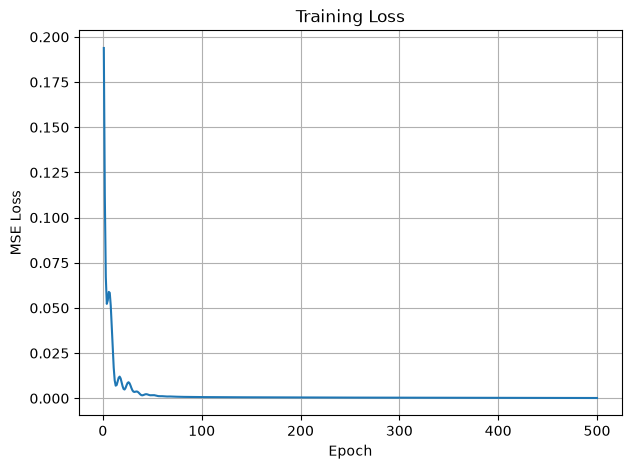

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(range(1, len(loss_history) + 1), loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

### Task 12 Observation

The loss should decrease as training progresses. This shows that the neural network is learning parameters that make its predicted values closer to the target values.

## Task 13 — Value Prediction

After training, use the neural network to estimate the value of the following states:

$$(0,0),\quad
(1,2),\quad
(2,3),\quad
(3,4),\quad
(4,4).
$$

Report the predicted values. Discuss whether the predictions for the states that were **not present in the training dataset** appear reasonable.

In [13]:
import torch

test_states = torch.tensor([
    [0., 0.],
    [1., 2.],
    [2., 3.],
    [3., 4.],
    [4., 4.]
])

model.eval()

with torch.no_grad():
    predicted_values = model(test_states)

print("Test states:")
print(test_states)

print("\nPredicted values:")
print(predicted_values)

Test states:
tensor([[0., 0.],
        [1., 2.],
        [2., 3.],
        [3., 4.],
        [4., 4.]])

Predicted values:
tensor([[0.0995],
        [0.4881],
        [0.6581],
        [0.8261],
        [0.9917]])


### Task 13 Observation

The states `(1,2)`, `(2,3)`, and `(3,4)` were not in the training dataset, so their values are interpolated by the neural network. If the predictions are reasonably close to the trend of the nearby target values, the network is generalizing the value function rather than only memorizing the training states.

# Part H — Learning Rate Experiment

The learning rate is an important hyperparameter in gradient-based learning.

Repeat the training experiment using $
\alpha=10^{-3}
$ instead of $
\alpha=10^{-2}.$

## Task 14 — Compare Learning Rates

Train the same neural network using both:

- Learning rate $10^{-2}$
- Learning rate $(10^{-3}$

Compare the two experiments.

Report:

1. Final training loss.
2. Convergence behavior.
3. Learning curves.

Answer:

> How does changing the learning rate affect the training of the value-function approximator?

In [14]:
learning_rate = 1e-3

# Create a new model
torch.manual_seed(42)
model_lr = ValueNetwork()

# Define loss and optimizer
criterion_lr = nn.MSELoss()
optimizer_lr = optim.Adam(model_lr.parameters(), lr=learning_rate)

epochs = 500
loss_history_lr = []

for epoch in range(epochs):

    # Forward pass
    y_pred_lr = model_lr(X)

    # Compute loss
    loss_lr = criterion_lr(y_pred_lr, y)

    # Backward pass
    optimizer_lr.zero_grad()
    loss_lr.backward()

    # Update parameters
    optimizer_lr.step()

    loss_history_lr.append(loss_lr.item())

    if (epoch + 1) % 50 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {loss_lr.item():.6f}"
        )

print("\nFinal loss for learning rate 1e-3:", loss_history_lr[-1])
print("Final loss for learning rate 1e-2:", loss_history[-1])

Epoch [50/500], Loss: 0.032148
Epoch [100/500], Loss: 0.007906
Epoch [150/500], Loss: 0.002590
Epoch [200/500], Loss: 0.001697
Epoch [250/500], Loss: 0.001295
Epoch [300/500], Loss: 0.001039
Epoch [350/500], Loss: 0.000877
Epoch [400/500], Loss: 0.000772
Epoch [450/500], Loss: 0.000704
Epoch [500/500], Loss: 0.000656

Final loss for learning rate 1e-3: 0.0006560505134984851
Final loss for learning rate 1e-2: 0.00017243348702322692


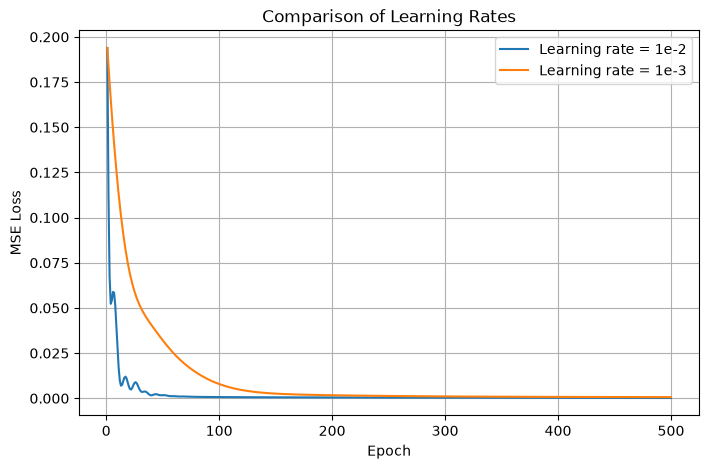

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(loss_history) + 1),
    loss_history,
    label="Learning rate = 1e-2"
)

plt.plot(
    range(1, len(loss_history_lr) + 1),
    loss_history_lr,
    label="Learning rate = 1e-3"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Comparison of Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

### Task 14 Observation

The learning rate of `1e-2` generally reduces the loss faster because the parameter updates are larger. The learning rate of `1e-3` makes smaller updates, so convergence is usually slower, although it can provide smoother training. The exact final losses depend slightly on the network initialization and training run.

# Part I — Reflection

Answer the following questions in approximately **2–4 sentences each**.

##### (a) Why is a neural network useful for approximating a value function when the state space becomes large?

##### (b) What is the difference between a tabular representation of $V(s)$ and a parameterized representation $V_\theta(s)$?

##### (c) Why is automatic differentiation useful when training a neural-network-based value function?

##### (d) In the stochastic GridWorld, why is it important to distinguish between the **requested action** and the **actual action executed by the environment**?

### Reflection Answers

**(a)** A neural network is useful because it can represent a large number of states using a relatively small set of parameters. It can also generalize to states that were not directly seen during training.

**(b)** In a tabular representation, a separate value is stored for every state. In a parameterized representation, the value is calculated using a function such as $V_\theta(s)$, whose parameters are learned.

**(c)** Automatic differentiation calculates the gradients of the loss with respect to the network parameters automatically. This makes it easier to train the value function using gradient-based optimization.

**(d)** The requested action is what the agent wants to do, while the actual action is what the stochastic environment executes. Keeping them separate is important because the difference determines the actual transition and reward received by the agent.

# Submission Requirements

Submit **one Jupyter/Google Colab notebook** containing:

1. Complete Python implementation.
2. Outputs from all required experiments.
3. Tables and plots wherever requested.
4. Answers to all conceptual questions.
5. Appropriate comments in the code.

Your notebook should be organized using suitable Markdown headings.

## Important

- Do not use code copied directly from external sources without understanding it.
- All results should be generated by executing your own notebook.
- Clearly indicate any assumptions made in your implementation.
- Use meaningful variable and function names.
- Ensure that the notebook can be executed from beginning to end without errors.

<!-- EE5531-XFGHK -->